In [1]:
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
import pandas as pd
import healpix as hp
import intake
from scipy import interpolate

# Plots
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import cmocean as cmo
import seaborn as sns
import cartopy.crs as ccrs
import easygems.healpix as egh
###
# Warnings
import warnings
warnings.filterwarnings(action='ignore')

# Global constants

In [2]:
EARTH_SURFACE = 510e6 # km2
ZOOM_COLORS_HISTORICAL =  {0: '#5CA0FF', 8: '#003175'}
ZOOM_COLORS_WARM =  {0: '#ff5ca0', 8: '#990033'}
VAR_SHORTNAME = {'2t': r'$\mathrm{T_{2m}}$', 'tp': 'pr', 'u': r'U$_\mathrm{700\,hPa}$'}
VAR_UNIT = {'2t': 'K', 'tp': r'mm$\,\mathrm{d}^{-1}$', 'u': r'm$\,\mathrm{s}^{-1}$'}
VAR_LABEL = {var: VAR_SHORTNAME[var] + ' / ' + VAR_UNIT[var] for var in list(VAR_UNIT.keys())}
SEASON_MONTH = {'all': np.arange(0, 12) + 1, 'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}

# Functions

In [3]:
def control_freak(factor = 1):
    # Fast function to control plot labels text size
    SMALL_SIZE = int(20 * factor)
    MEDIUM_SIZE = int(22 * factor)
    BIGGER_SIZE = int(26 * factor)

    plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
    return [SMALL_SIZE, MEDIUM_SIZE, BIGGER_SIZE]

In [4]:
print_basic_info_dataset = lambda ds, var: print(f"From {str(ds.time.values[0])[:10]} to {str(ds.time.values[-1])[:10]} | ncells {ds.cell.size: .2e} |  nside {hp.npix2nside(ds.cell.size)} | " + 
                                                 f"Grid area {EARTH_SURFACE / ds.cell.size :.2f} km2 or spacing of about {np.sqrt(EARTH_SURFACE / ds.cell.size): .2f} km" + 
                                                 f" | nbytes {ds['2t'].nbytes * 1e-6: .2f} MBs" if var is None else f"nbytes {ds[var].nbytes * 1e-6: .2f} MBs")

In [5]:
f_mean_average_error = lambda ds, ds_ref: np.linalg.norm(ds - ds_ref, 1) / ds.size

In [6]:
f_intersection = lambda a, b: np.array(list(set(a).intersection(b)))
f_difference = lambda a, b: np.array(list(set(a).difference(b)))

In [7]:
def get_lon_lat(ds, dim_cell='cell', nest=True):
    nside = hp.npix2nside(ds[dim_cell].size)
    lon, lat = hp.pix2ang(nside, np.arange(ds[dim_cell].size), nest=nest, lonlat=True)
    lon = (lon + 180) % 360 - 180
    return lon, lat

# Data 

As in the previous notebooks, we get the data from the km-scale global hackathon for ERA5 for three different zoom levels, 0, 3, 6, and 8

In [8]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/online.yaml")

We want only three variables of those dataset:

- near surface temperature -> `2t` in K
- precipitation -> `tp` measured as total precipitation in meters but we want it in mm d$^{-1}$ (factor = 1e3)
- surface pressure -> `sp`in Pa

For the time dimension, we want to use ERA5 from 2025 to 2020

In [9]:
variables = ['2t', 'tp', 'u']

Let's only take the relevant years, 1950-2020

In [10]:
ds_era5_zoom_0 = cat['ERA5'](zoom=0).to_dask()[variables].sel(time=slice('1950-01-01', '2020-12-31'))
ds_era5_zoom_8 = cat['ERA5'](zoom=8).to_dask()[variables].sel(time=slice('1950-01-01', '2020-12-31'))
print_basic_info_dataset(ds_era5_zoom_0, None), print_basic_info_dataset(ds_era5_zoom_8, None);

From 1950-01-01 to 2020-12-01 | ncells  1.20e+01 |  nside 1 | Grid area 42500000.00 km2 or spacing of about  6519.20 km | nbytes  0.04 MBs
From 1950-01-01 to 2020-12-01 | ncells  7.86e+05 |  nside 256 | Grid area 648.50 km2 or spacing of about  25.47 km | nbytes  2680.16 MBs


We will split the data in two periods

- Historical period between 1950 and 1980
- Milenials period between 1981 and 2020

# Work

## Anomalies and the seasonal cycle

In [11]:
f_anomalies = lambda da, da_ref: da.groupby("time.month") - da_ref.groupby("time.month").mean("time")

In [12]:
def get_tendencies_1D(ds_use, t_start, t_end):
    years_timestamp = ds_use.time.sel(time=slice(t_start, t_end)).resample(time='1Y').mean().time.values
    years_ = [pd.Timestamp(x).year for x in years_timestamp]
    m_, b_ = coef = np.polyfit(years_, ds_use.sel(time=slice(t_start, t_end)).resample(time='1Y').mean().values, 1)
    p = np.poly1d(coef)
    return xr.DataArray(data=p(years_), dims=["time", ], coords={'time': years_timestamp}), m_, b_

In [13]:
ds_glb_2t_historical = ds_era5_zoom_0['2t'].sel(time=slice('1950-01-01', '1980-12-31')).mean('cell').squeeze(drop=True).compute()
ds_glb_2t_milenials = ds_era5_zoom_0['2t'].sel(time=slice('1981-01-01', '2020-12-31')).mean('cell').squeeze(drop=True).compute()

In [14]:
ds_glb_2t_anomalies = f_anomalies(ds_glb_2t_milenials, ds_glb_2t_historical)

In [15]:
ds_2t_anomalies_yearly = f_anomalies(ds_era5_zoom_8['2t'].sel(time=slice('1981-01-01', '2020-12-31')), ds_era5_zoom_8['2t'].sel(time=slice('1950-01-01', '1980-12-31'))).resample(time='1Y').mean().compute()

### Plot global mean anomalies

In [ ]:
sns.set_context('talk')
hist_color, mile_color = ZOOM_COLORS_HISTORICAL[8], ZOOM_COLORS_WARM[8]
control_freak(.6)
fig, ax = plt.subplots(1, 2, figsize=(20, 4), constrained_layout=True, facecolor='white', dpi=75)
## Seasonal cycle
mu, std = ds_glb_2t_historical.groupby("time.month").mean("time"), ds_glb_2t_historical.groupby("time.month").std("time")
mu.plot(ax=ax[0], color=hist_color, alpha=1, zorder=4, label=r'$\overline{1950-1980}$')
ax[0].fill_between(mu.month.values, (mu + std).values, (mu - std).values, color=hist_color, alpha=0.25, zorder=2)
#
mu, std = ds_glb_2t_milenials.groupby("time.month").mean("time"), ds_glb_2t_milenials.groupby("time.month").std("time")
mu.plot(ax=ax[0], color=mile_color, alpha=1, zorder=5, label=r'$\overline{1981-2020}$')
ax[0].fill_between(mu.month.values, (mu + std).values, (mu - std).values, color=mile_color, alpha=0.25, zorder=3)
ax[0].set(xlabel='t / month', ylabel=VAR_LABEL['2t'], title='Seasonal cycle')
ax[0].set_xlim([0.5, 12.5])
ax[0].set_xticks(np.arange(1, 13))
ax[0].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
leg = ax[0].legend(frameon=False)
sns.despine(ax=ax[0], offset=15)
## Anomalies
ds_glb_2t_anomalies.plot(ax=ax[1], color='silver', ls='--', zorder=2)
ds_glb_2t_anomalies.resample(time='1Y').mean().plot(ax=ax[1], color='gray', ls='-', zorder=3)
# Tendencies
fitted, m, b = coef = get_tendencies_1D(ds_glb_2t_anomalies, '1981-01-01', '2020-12-31')
fitted.plot(ax=ax[1], color='k', lw=5, zorder=4)
ax[1].text(0.61, 0.15, r'$\mathrm{m_{1980-2020}}\,=\,$' + f"{m * 10:.3f} " + VAR_UNIT['2t'] + " per decade", transform=ax[1].transAxes,
           fontsize=14, va='top', ha='left', color='k')
ax[1].set(xlabel=r't / year', ylabel=r'$\Delta\,$' + f"{VAR_LABEL['2t']}")
sns.despine(ax=ax[1], offset=15)
plt.savefig(f"Fig/ERA5_global_mean_2t_anomalies.png", format='png', dpi=128, transparent=False, bbox_inches='tight')

### Plot regional changes and tendencies

In [17]:
def get_2d_tendencies(ds):
    years_ = [pd.Timestamp(x).year for x in ds.time.values]
    f_get_tendency = lambda data: np.polyfit(years_, data, 1)[0]
    return xr.apply_ufunc(
        f_get_tendency, ds_2t_anomalies_yearly, 
        keep_attrs=True,
        input_core_dims=[["time"]],
        output_dtypes=["f4"],
        vectorize=True,
        dask="parallelized",
        )

In [18]:
ds_2t_tendencies = get_2d_tendencies(ds_2t_anomalies_yearly) * 10

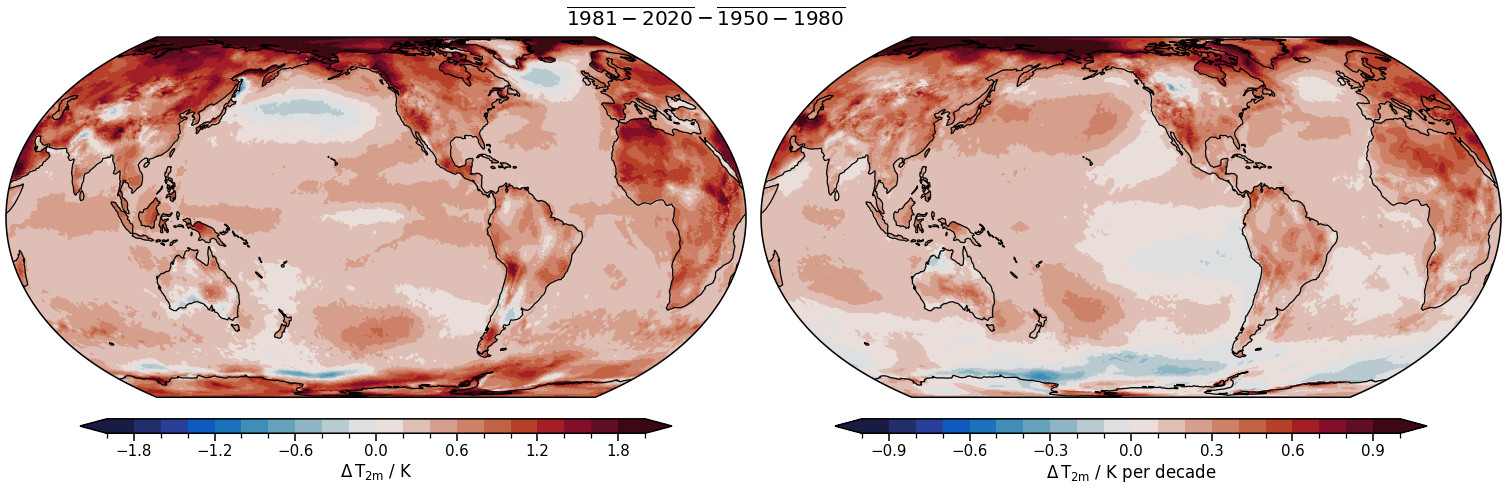

In [36]:
ds_diff, ds_tend = ds_use = ds_2t_anomalies_yearly.mean('time'), ds_2t_tendencies
vmin_use = [2, 1]
# Plot
cmap = cmo.cm.balance
projection = ccrs.EqualEarth(-135.58) # ccrs.NearsidePerspective(0, 0) ccrs.Robinson() 
fig, ax = plt.subplots(1, 2, figsize=(25, 8), subplot_kw={"projection": projection}, constrained_layout=True, facecolor='white', dpi=60)
# 
[ax_.set_global() for ax_ in ax]
[ax_.coastlines() for ax_ in ax]
#
for i in range(2):
    bounds = np.linspace(-vmin_use[i], vmin_use[i], 21)
    norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256) #colors.Normalize(vmin, vmax)
    im = cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(im, ax=ax[i], cax=ax[i].inset_axes([0.1, -0.1, 0.8, 0.04]), orientation='horizontal', extend='both')
    cbar.ax.tick_params(labelsize=18)
    cbar.set_label(label=r'$\Delta\,$' + VAR_LABEL['2t'], fontsize=20) if i == 0 else cbar.set_label(label=r'$\Delta\,$' + VAR_LABEL['2t'] + ' per decade', fontsize=20)
    egh.healpix_show(ds_use[i], ax=ax[i], cmap=cmap, norm=norm)

fig.suptitle(r'$\overline{1981-2020} - \overline{1950-1980}$', x=0.375, y=1.0, 
             fontsize=24, va='top', ha='left', weight='bold');
plt.savefig(f"Fig/ERA5_regional_mean_2t_anomalies.png", format='png', dpi=128, transparent=False, bbox_inches='tight')

## Hovmuller diagram 

We want investigate the monsoon rainfall in the Sahel region ([Da-Allada et al. 2020](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2020EF001595)). 
Thus, we want to do a [Hovmuller](https://en.wikipedia.org/wiki/Hovm%C3%B6ller_diagram) diagram of monthly mean rainfall averaged over the longitudes 10W and 10E for the period historical and milenial period within the latitudes 10S and 20N.

In the plot we can indicate the 5N to approximate the Guinean coast and 10N as the arrival of monoon rainfall in the Sahel region.

In [20]:
# First we need to know the idx of interest
lon_z8, lat_z8 = get_lon_lat(ds_era5_zoom_8)
idx_sahel_z8 = f_intersection(np.where((lon_z8 > -10) & (lon_z8 < 10))[0], np.where((lat_z8 > -10) & (lat_z8 < 20))[0])

In [21]:
ds_historical_sahel_z8 = ds_era5_zoom_8['tp'].sel(time=slice('1950-01-01', '1980-12-31')).isel(cell=idx_sahel_z8).squeeze(drop=True).groupby("time.month").mean("time").compute()
ds_milenial_sahel_z8 = ds_era5_zoom_8['tp'].sel(time=slice('1981-01-01', '2020-12-31')).isel(cell=idx_sahel_z8).squeeze(drop=True).groupby("time.month").mean("time").compute()

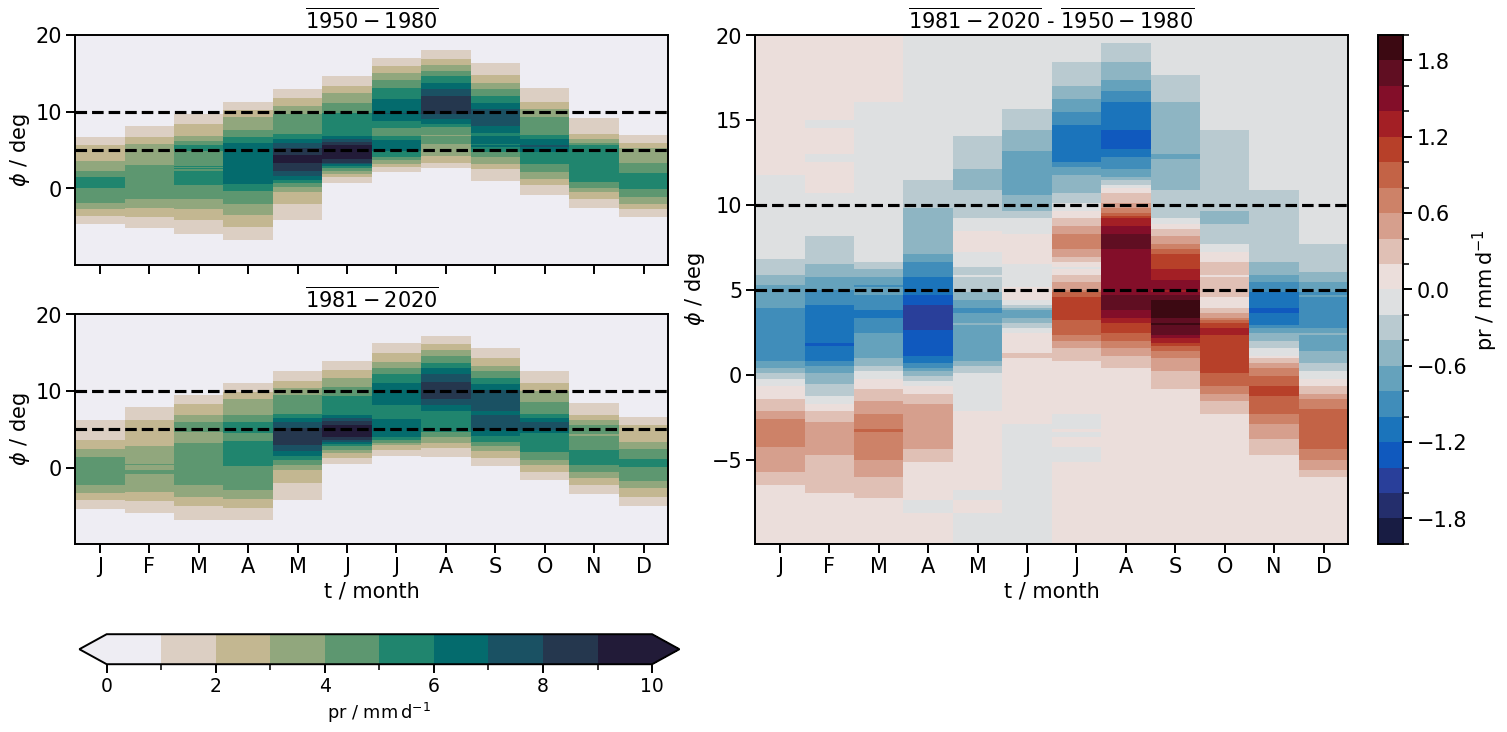

In [37]:
sns.set_context('talk')
control_freak(1)
fig, ax = plt.subplots(2, 2, figsize=(20, 8), constrained_layout=True, facecolor='white', dpi=75, sharex=True)
gs = ax[1, 0].get_gridspec()
for ax_ in ax[:, -1]:
    ax_.remove()
axbig = fig.add_subplot(gs[0:, 1])
# Colorbar
cmap = cmo.cm.rain
bounds = np.linspace(0, 10, 11)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256) #colors.Normalize(vmin, vmax)
im = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(im, ax=ax.ravel().tolist(), cax=fig.add_axes([0.05, -0.1, 0.4, 0.05]), orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=18)
cbar.set_label(label=VAR_LABEL['tp'], size=17)
## Seasonal cycle
mu = ds_historical_sahel_z8.groupby("lat").mean() * 1e3
mu.T.plot(ax=ax[0, 0], cmap=cmap, norm=norm, add_colorbar=False,)
ax[0, 0].set(title=r'$\overline{1950-1980}$', xlabel='', ylabel=r'$\phi$ / deg')

mu = ds_milenial_sahel_z8.groupby("lat").mean() * 1e3
mu.T.plot(ax=ax[1, 0], cmap=cmap, norm=norm, add_colorbar=False,)
ax[1, 0].set(title=r'$\overline{1981-2020}$', xlabel='t / month', ylabel=r'$\phi$ / deg')
ax[1, 0].set_xticks(np.arange(1, 13))
ax[1, 0].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']);
## Diff seasonal cycle
mu = (ds_milenial_sahel_z8.groupby("lat").mean() - ds_historical_sahel_z8.groupby("lat").mean()) * 1e3 
mu.T.plot(ax=axbig, cmap=cmo.cm.balance, norm=colors.BoundaryNorm(boundaries=np.linspace(-2, 2, 21), ncolors=256), 
          add_colorbar=True, cbar_kwargs={"label": VAR_LABEL['tp']})
axbig.set(title=r'$\overline{1981-2020}$ - $\overline{1950-1980}$', xlabel='t / month', ylabel=r'$\phi$ / deg')
axbig.set_xticks(np.arange(1, 13))
axbig.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']);
[ax_.axhline(y=5, color='k', zorder=3, ls='--', lw=3) for ax_ in [ax[0, 0], ax[1, 0], axbig]];
[ax_.axhline(y=10, color='k', zorder=3, ls='--', lw=3) for ax_ in [ax[0, 0], ax[1, 0], axbig]];

plt.savefig(f"Fig/ERA5_hovmuller_sahel_region.png", format='png', dpi=128, transparent=False, bbox_inches='tight')

## The Jet Stream

The jet stremas has many implications as its strenghtening and locations are correlated with the intensification of Caribbean rainstorms and the location of them.
There are two main jet streams, the subptropical and the eddie-driven jet. 
Both jets have many ways to be computed (e.g, [Adam et al. 2018](https://gmd.copernicus.org/articles/11/4339/2018/)), which lead to minor discrepancies in methodology and results.

In our case we will follow the methodology and analysis of [Breul et al. 2025](https://www.nature.com/articles/s43017-025-00749-9?fromPaywallRec=false) to evaluate the four differnt seasons of the zonal wind climatology during the historical period. Thus, we use the 700 hPa zonal wind.
We will also evaluate the intensification of the north and southern eddie-driven jet by evaluating the anomalies of the milenial period to the historical.
We can use the methodlogy explained in [Adam et al. (2018)](https://gmd.copernicus.org/articles/11/4339/2018/) for the location and intensity.

In [23]:
ds_historical_zonal_wind_z8 = ds_era5_zoom_8['u'].sel(time=slice('1950-01-01', '1980-12-31')).sel(level=700).squeeze(drop=True)
ds_milenial_zonal_wind_z8 = ds_era5_zoom_8['u'].sel(time=slice('1981-01-01', '2020-12-31')).sel(level=700).squeeze(drop=True)

In [24]:
ds_historical_zonal_wind_z8['lat'] = ds_historical_zonal_wind_z8.lat.load()
ds_milenial_zonal_wind_z8['lat'] = ds_historical_zonal_wind_z8.lat.load()

In [25]:
ds_historical_zonal_wind_zonal_mean = ds_historical_zonal_wind_z8.groupby("lat").mean().compute()
ds_milenial_zonal_wind_zonal_mean = ds_milenial_zonal_wind_z8.groupby("lat").mean().compute()

In [26]:
ds_historical_zonal_wind_month = ds_historical_zonal_wind_z8.groupby("time.month").mean("time").compute()
ds_milenial_zonal_wind_month = ds_milenial_zonal_wind_z8.groupby("time.month").mean("time").compute()

### Plot Eddie-driven jet

In [27]:
season = 'all'
ds_season_2d_his = ds_historical_zonal_wind_month.sel(month=SEASON_MONTH[season]).mean('month')
ds_season_zonal_his = ds_season_2d_his.groupby("lat").mean().compute()
ds_season_2d_mil = ds_milenial_zonal_wind_month.sel(month=SEASON_MONTH[season]).mean('month')
ds_season_zonal_mil = ds_season_2d_mil.groupby("lat").mean().compute()

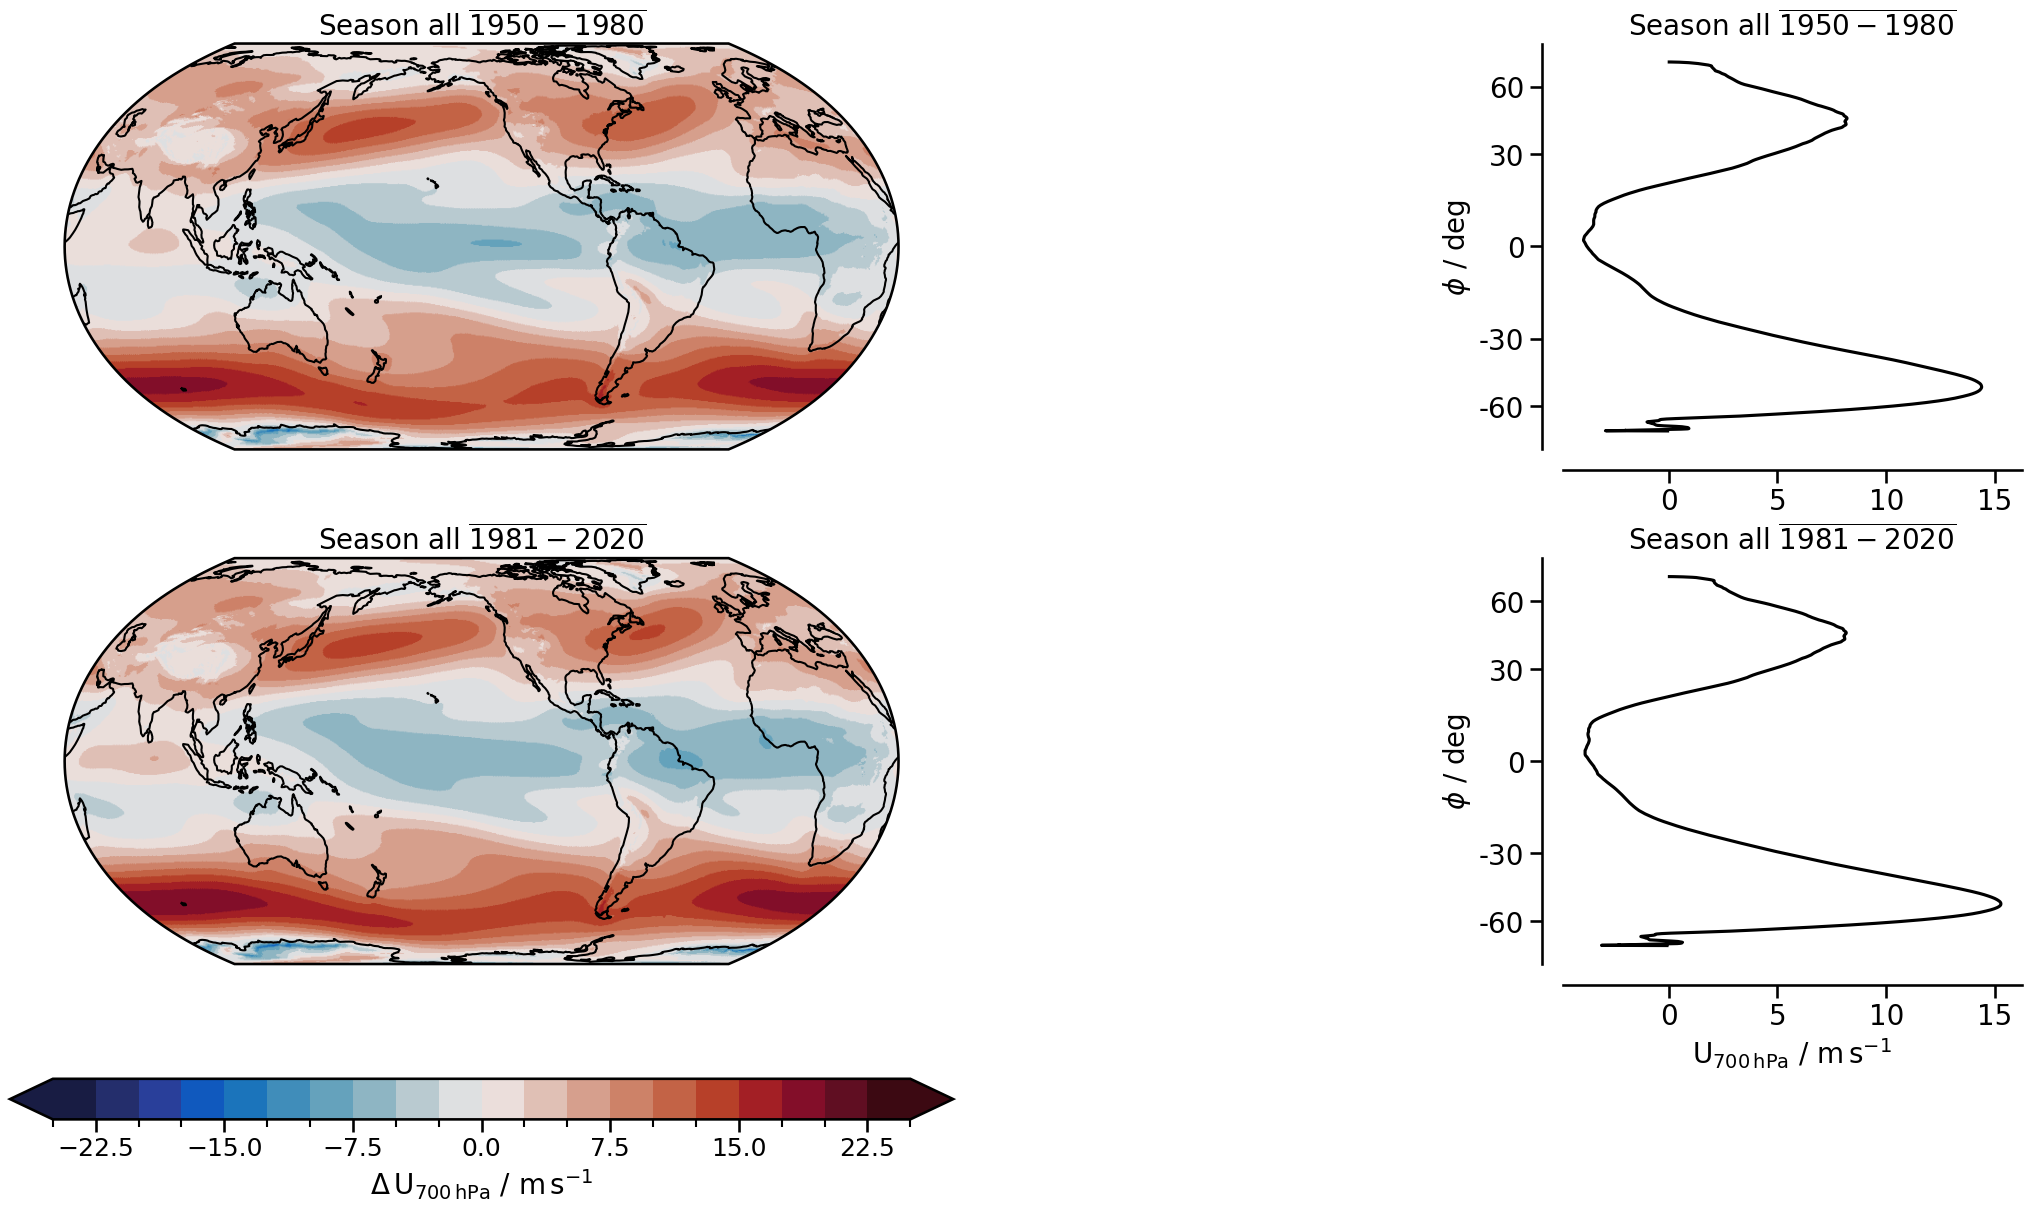

In [38]:
fig = plt.figure(figsize=(25, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 5, width_ratios=[1, 1, 1, 1, 1], height_ratios=[10, 10, 1], wspace=0, hspace=0)
projection = ccrs.EqualEarth(-135.58) # ccrs.NearsidePerspective(0, 0) ccrs.Robinson() 
lat_ticks = np.array([-60, -30, 0, 30, 60])
## Add Grids
ax1 = fig.add_subplot(gs[0, :4], projection=projection)
ax2 = fig.add_subplot(gs[0, 4])
ax3 = fig.add_subplot(gs[1, :4], projection=projection, sharex=ax1)
ax4 = fig.add_subplot(gs[1, 4], sharex=ax2)
[ax_.set_global() for ax_ in [ax1, ax3]]
[ax_.coastlines() for ax_ in [ax1, ax3]]
## Colorbar
cmap = cmo.cm.balance
bounds = np.linspace(-25, 25, 21)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256) #colors.Normalize(vmin, vmax)
im = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(im, ax=ax, cax=fig.add_subplot(gs[2,1:3]), orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=18)
cbar.set_label(label=r'$\Delta\,$' + VAR_LABEL['u'], fontsize=20)
## Plots
egh.healpix_show(ds_season_2d_his, ax=ax1, cmap=cmap, norm=norm)
egh.healpix_show(ds_season_2d_mil, ax=ax3, cmap=cmap, norm=norm)
ax2.plot(ds_season_zonal_his.values, np.sin(np.deg2rad(ds_season_zonal_his.lat)), color='k')
ax4.plot(ds_season_zonal_mil.values, np.sin(np.deg2rad(ds_season_zonal_mil.lat)), color='k')
[ax_.set(title=f"Season {season} " + r'$\overline{1950-1980}$') for ax_ in [ax1, ax2]]
[ax_.set(title=f"Season {season} " + r'$\overline{1981-2020}$') for ax_ in [ax3, ax4]]
[sns.despine(ax=ax_, offset=15) for ax_ in [ax2, ax4]]
[ax_.set_ylabel(r'$\phi$ / deg') for ax_ in [ax2, ax4]]
[ax_.set_yticks(np.sin(np.deg2rad(lat_ticks))) for ax_ in [ax2, ax4]]
[ax_.set_yticklabels(lat_ticks) for ax_ in [ax2, ax4]]
ax4.set_xlabel(VAR_LABEL['u'])

plt.savefig(f"Fig/ERA5_eddie_drive_jet_season_{season}.png", format='png', dpi=128, transparent=False, bbox_inches='tight')

### Plot/find eddie-driven jet (lat and intensity)

In [29]:
def get_eddie_drive_jet(ds, hemisphere='NH', n=8):
    ds_ = ds.sel(lat=slice(-90, 0)) if hemisphere=='SH' else ds.sel(lat=slice(0, 90))
    lat_ = ds_.lat.values.flatten()
    def get_maxima_lat_val(values):
        cs = interpolate.CubicSpline(lat_, values.flatten())
        max_point = np.sum(np.multiply(values ** 8, lat_)) / np.sum(values ** 8)
        max_lat = cs(max_point)
        return max_lat, max_point
    da_maxima, da_lat_maxima = xr.apply_ufunc(
        get_maxima_lat_val, ds_, 
        keep_attrs=True,
        input_core_dims=[["lat"]],
        output_core_dims=[[], []],
        output_dtypes=["f4", "f4"],
        vectorize=True,
        dask="parallelized",
        )
    return xr.merge([da_maxima.to_dataset(name='u_max'), da_lat_maxima.to_dataset(name='u_lat')])

In [30]:
ds_edj_hist_nh = get_eddie_drive_jet(ds_historical_zonal_wind_zonal_mean, hemisphere='NH', n=8)
ds_edj_hist_sh = get_eddie_drive_jet(ds_historical_zonal_wind_zonal_mean, hemisphere='SH', n=8)

In [31]:
ds_edj_mil_nh = get_eddie_drive_jet(ds_milenial_zonal_wind_zonal_mean, hemisphere='NH', n=8)
ds_edj_mil_sh = get_eddie_drive_jet(ds_milenial_zonal_wind_zonal_mean, hemisphere='SH', n=8)

In [32]:
ds_edj_nh_anomalies = f_anomalies(ds_edj_mil_nh, ds_edj_hist_nh)
ds_edj_sh_anomalies = f_anomalies(ds_edj_mil_sh, ds_edj_hist_sh)

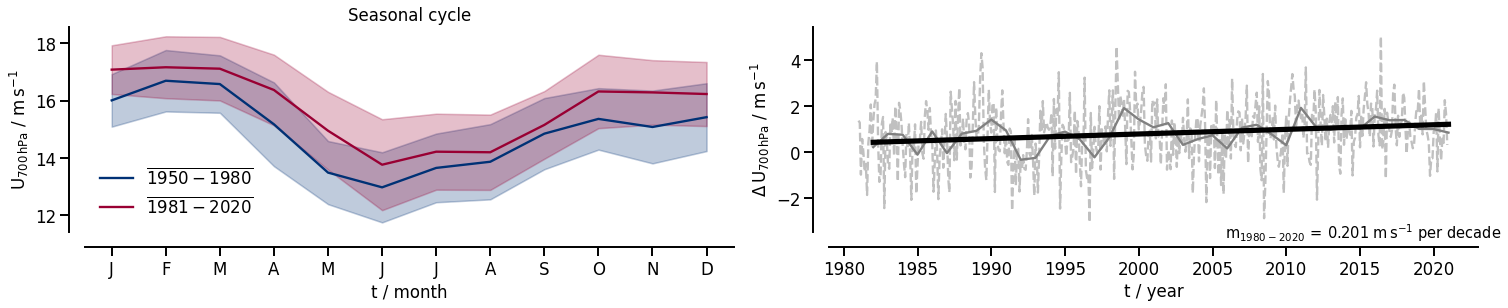

In [39]:
sns.set_context('talk')
var, region = 'u_max', 'SH' # u_lat, u_max and NH, SH
label = VAR_LABEL['u'] if var == 'u_max' else r'$\mathrm{u^{\phi}_{700 hPa}}$ / deg'
units = VAR_UNIT['u'] if var == 'u_max' else 'deg'
hist_color, mile_color = ZOOM_COLORS_HISTORICAL[8], ZOOM_COLORS_WARM[8]
ds_hist_use = ds_edj_hist_nh[var] if region == 'NH' else ds_edj_hist_sh[var]
ds_mil_use = ds_edj_mil_nh[var] if region == 'NH' else ds_edj_mil_sh[var]
ds_anomaly_use = ds_edj_nh_anomalies[var] if region == 'NH' else ds_edj_sh_anomalies[var]
control_freak(.8)
fig, ax = plt.subplots(1, 2, figsize=(20, 4), constrained_layout=True, facecolor='white', dpi=75)
## Seasonal cycle
mu, std = ds_hist_use.groupby("time.month").mean("time"), ds_hist_use.groupby("time.month").std("time")
mu.plot(ax=ax[0], color=hist_color, alpha=1, zorder=4, label=r'$\overline{1950-1980}$')
ax[0].fill_between(mu.month.values, (mu + std).values, (mu - std).values, color=hist_color, alpha=0.25, zorder=2)
#
mu, std = ds_mil_use.groupby("time.month").mean("time"), ds_mil_use.groupby("time.month").std("time")
mu.plot(ax=ax[0], color=mile_color, alpha=1, zorder=5, label=r'$\overline{1981-2020}$')
ax[0].fill_between(mu.month.values, (mu + std).values, (mu - std).values, color=mile_color, alpha=0.25, zorder=3)
ax[0].set(xlabel='t / month', ylabel=label, title='Seasonal cycle')
ax[0].set_xlim([0.5, 12.5])
ax[0].set_xticks(np.arange(1, 13))
ax[0].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
leg = ax[0].legend(frameon=False)
sns.despine(ax=ax[0], offset=15)
## Anomalies
ds_anomaly_use.plot(ax=ax[1], color='silver', ls='--', zorder=2)
ds_anomaly_use.resample(time='1Y').mean().plot(ax=ax[1], color='gray', ls='-', zorder=3)
# Tendencies
fitted, m, b = coef = get_tendencies_1D(ds_anomaly_use, '1981-01-01', '2020-12-31')
fitted.plot(ax=ax[1], color='k', lw=5, zorder=4)
ax[1].text(0.61, 0.05, r'$\mathrm{m_{1980-2020}}\,=\,$' + f"{m * 10:.3f} {units} per decade", transform=ax[1].transAxes,
           fontsize=14, va='top', ha='left', color='k')
ax[1].set(xlabel=r't / year', ylabel=r'$\Delta\,$' + label)
sns.despine(ax=ax[1], offset=15)
plt.savefig(f"Fig/ERA5_eddie_drive_jet_{var}_{region}_anomalies_yearly.png", format='png', dpi=128, transparent=False, bbox_inches='tight')

# Correlations

In [34]:
ds_2t_anomalies_glb = f_anomalies(ds_era5_zoom_0['2t'].sel(time=slice('1981-01-01', '2020-12-31')).mean('cell').squeeze(drop=True).compute(), 
                                  ds_era5_zoom_0['2t'].sel(time=slice('1950-01-01', '1980-12-31')).mean('cell').squeeze(drop=True).compute())
ds_pr_anomalies_glb = f_anomalies(ds_era5_zoom_0['tp'].sel(time=slice('1981-01-01', '2020-12-31')).mean('cell').squeeze(drop=True).compute(), 
                                  ds_era5_zoom_0['tp'].sel(time=slice('1950-01-01', '1980-12-31')).mean('cell').squeeze(drop=True).compute())

In [35]:
df_anomalies_monthly = pd.DataFrame(
    {
        'u_max_nh': ds_edj_nh_anomalies.u_max.values, 
        'u_max_sh': ds_edj_sh_anomalies.u_max.values, 
        'u_lat_nh': ds_edj_nh_anomalies.u_lat.values,
        'u_lat_sh': ds_edj_sh_anomalies.u_lat.values,  
        'T': ds_2t_anomalies_glb.values,
        'pr': ds_pr_anomalies_glb.values,
    }
)
df_anomalies_monthly.index = ds_edj_nh_anomalies.time.values

NameError: name 'ds_pr_anomalies_yearly' is not defined

In [ ]:
df_anomalies_yearly = df_anomalies_monthly.resample("Y").mean()

In [ ]:
corr_pearson = df_anomalies_yearly.corr(method='pearson')

In [ ]:
# Nice plot
cmap = cmo.cm.balance
#
mask = np.zeros_like(corr_pearson, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr_pearson[mask] = np.nan
(corr_pearson.style.background_gradient(cmap=cmap, axis=None, vmin=-1, vmax=1)
    .set_properties(**{'font-size': '12pt'}).highlight_null(color='#f1f1f1')
)

# Questions?